C:\Users\user\AppData\Local\Temp\ipykernel_13040\4121105521.py:59: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "*-b" (-> color='b'). The keyword argument will take precedence.
  plt.plot(x_orig, y_orig, '*-b', label='Original Line', color = "black")
C:\Users\user\AppData\Local\Temp\ipykernel_13040\4121105521.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "o--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot(transformed[0], transformed[1], 'o--r', label='Scaled Line', color = "silver")


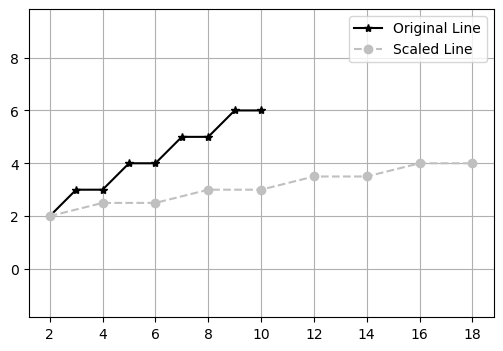

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def bresenham_line(x0, y0, x1, y1):
    xes, yes = [], []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x1 >= x0 else -1
    sy = 1 if y1 >= y0 else -1
    x, y = x0, y0
    if dx >= dy:
        p = 2 * dy - dx
        for _ in range(dx + 1):
            xes.append(x)
            yes.append(y)
            x += sx
            if p >= 0:
                y += sy
                p += 2 * dy - 2 * dx
            else:
                p += 2 * dy
    else:
        p = 2 * dx - dy
        for _ in range(dy + 1):
            xes.append(x)
            yes.append(y)
            y += sy
            if p >= 0:
                x += sx
                p += 2 * dx - 2 * dy
            else:
                p += 2 * dx
    return np.array(xes), np.array(yes)

def fixed_point_scaling_start(x0, y0, x1, y1, sx, sy):
    x_orig, y_orig = bresenham_line(x0, y0, x1, y1)

    # Scaling about starting point
    T_to_origin = np.array([
        [1, 0, -x0],
        [0, 1, -y0],
        [0, 0, 1]
    ])
    scaling = np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])
    T_back = np.array([
        [1, 0, x0],
        [0, 1, y0],
        [0, 0, 1]
    ])
    composite = T_back @ scaling @ T_to_origin
    points = np.vstack([x_orig, y_orig, np.ones_like(x_orig)])
    transformed = composite @ points

    plt.figure(figsize=(6,4))
    plt.plot(x_orig, y_orig, '*-b', label='Original Line', color = "black")
    plt.plot(transformed[0], transformed[1], 'o--r', label='Scaled Line', color = "silver")
    plt.legend(); plt.grid(True); plt.axis('equal')
    plt.show()

# Example usage
fixed_point_scaling_start(2, 2, 10, 6, 2, 0.5)
